# Setup

In [1]:
import pandas as pd
import hammock_plot
import plotly.express as px
import kaleido

In [2]:
# data upload and column renaming
df_penguins = pd.read_csv("data_penguins.csv")
df_penguins["bill length (mm)"] = df_penguins["bill_length_mm"]
df_penguins["bill depth (mm)"] = df_penguins["bill_depth_mm"]

In [3]:
# variable list
var_list = ["species", "island", "bill length (mm)", "bill depth (mm)"]

# label options
label_options = {}
for var in var_list:
    label_options[var] = {'fontsize': 18}

large_label_options = {}
for var in var_list:
    large_label_options[var] = {'fontsize': 23}

# Examples

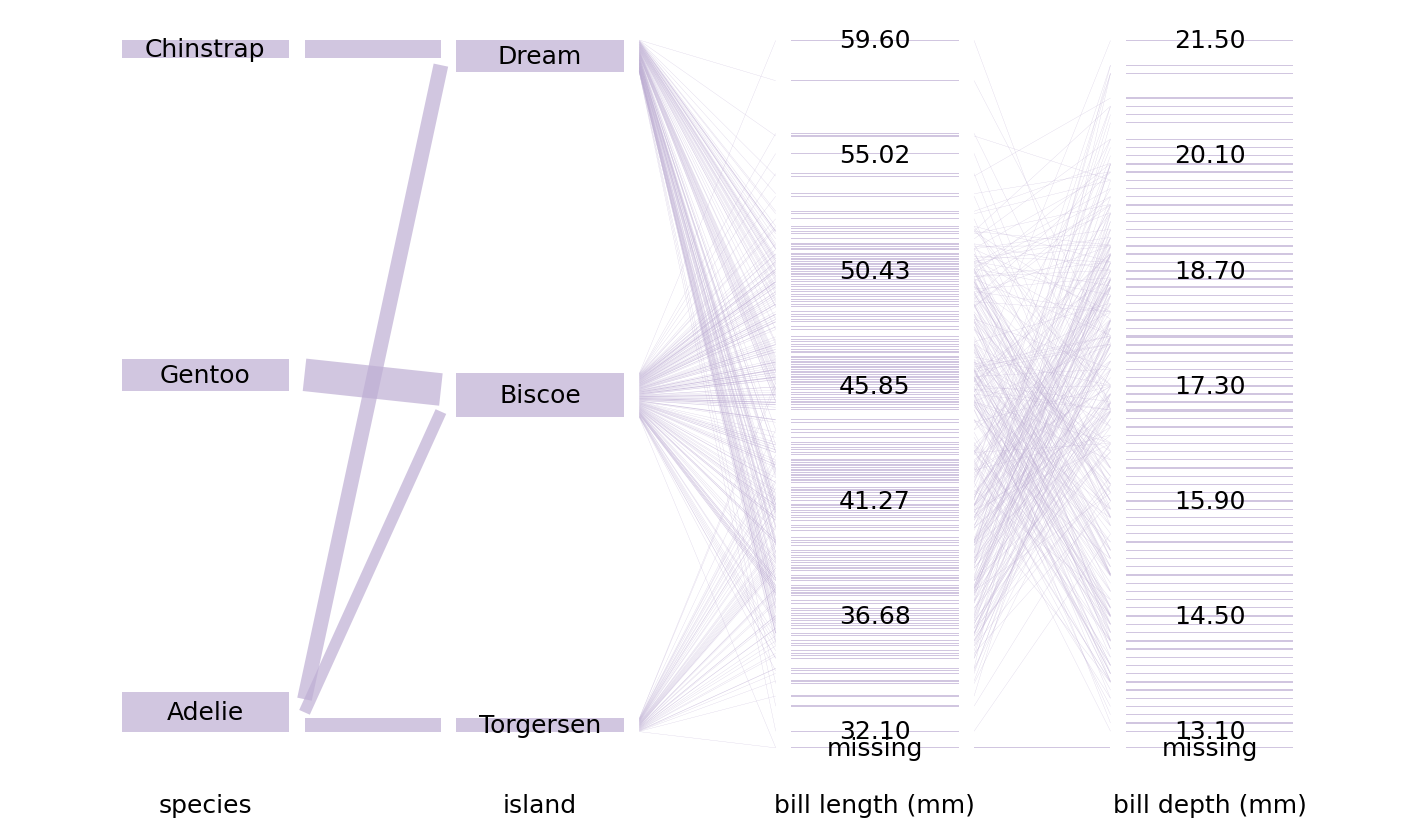

In [4]:
# minimal example
hammock = hammock_plot.Hammock(df_penguins)
ax = hammock.plot(
    var= var_list,
    display_figure=True,
    missing=True,
    uni_vfill=0.15,
    label_options=label_options,
    uni_hfill=0.5,
    width=18,
)

In [ ]:
# parallel sets version
df_quintiles = df_penguins.copy()

for col in ["bill length (mm)", "bill depth (mm)"]:
    df_quintiles[col] = pd.qcut(
        df_quintiles[col],
        q=5,
        precision=2,
        duplicates="drop"
    ).astype(str)

df_quintiles["_color"] = 0  # constant so all ribbons get the same color

df_quintiles = df_quintiles.fillna("missing").replace("nan", "missing")

fig = px.parallel_categories(
    df_quintiles,
    dimensions=var_list,
    color="_color",
    color_continuous_scale=["#beaed4", "#beaed4"]
)

# put missing at the end
fig.update_traces(
    dimensions=[
        dict(values=df_quintiles[col], label=col, categoryorder="array", categoryarray=cats)
        for col, cats in {
            col: sorted([c for c in df_quintiles[col].unique() if c != "missing"]) + ["missing"]
            for col in var_list
        }.items()
    ]
)
fig.update_layout(coloraxis_showscale=False)

fig.show()

# save image
# fig.write_image("figures/parset_example.png", scale=3)

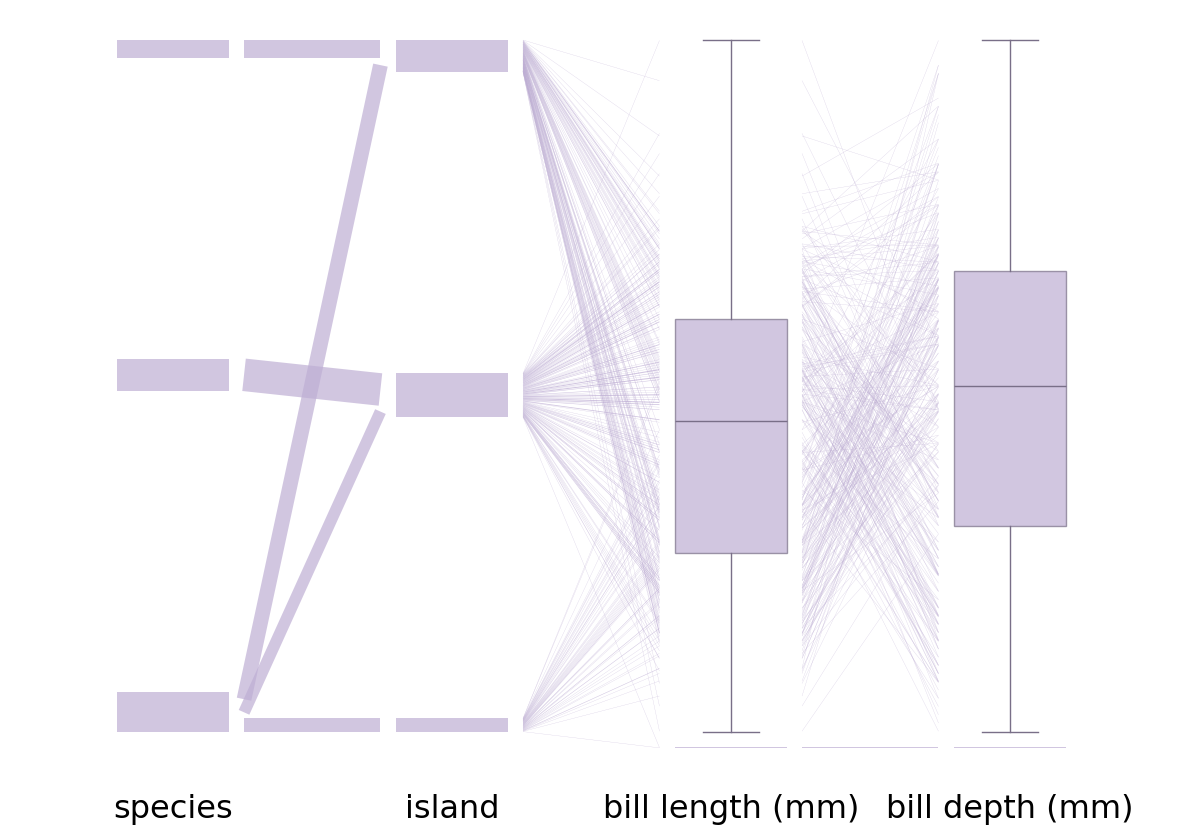

In [6]:
# box plots
hammock = hammock_plot.Hammock(df_penguins)
ax = hammock.plot(
    var= var_list,
    display_figure=True,
    missing=True,
    uni_vfill=0.15,
    label_options=large_label_options,
    label=False,
    uni_hfill=0.4,
    display_type={"bill length (mm)": "box", "bill depth (mm)": "box"},
)

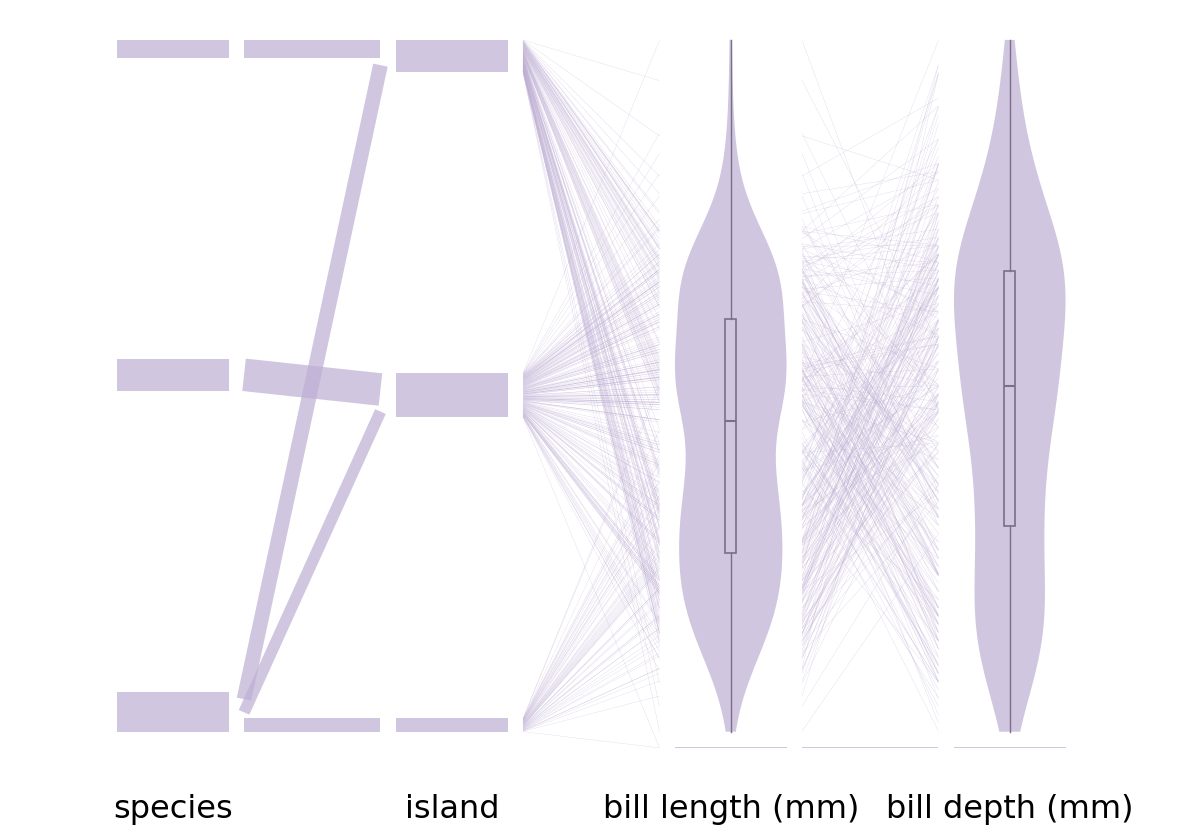

In [7]:
# violin plots
hammock = hammock_plot.Hammock(df_penguins)
ax = hammock.plot(
    var= var_list,
    display_figure=True,
    missing=True,
    label=False,
    uni_vfill=0.15,
    label_options=large_label_options,
    uni_hfill=0.4,
    display_type={"bill length (mm)": "violin", "bill depth (mm)": "violin"},
)

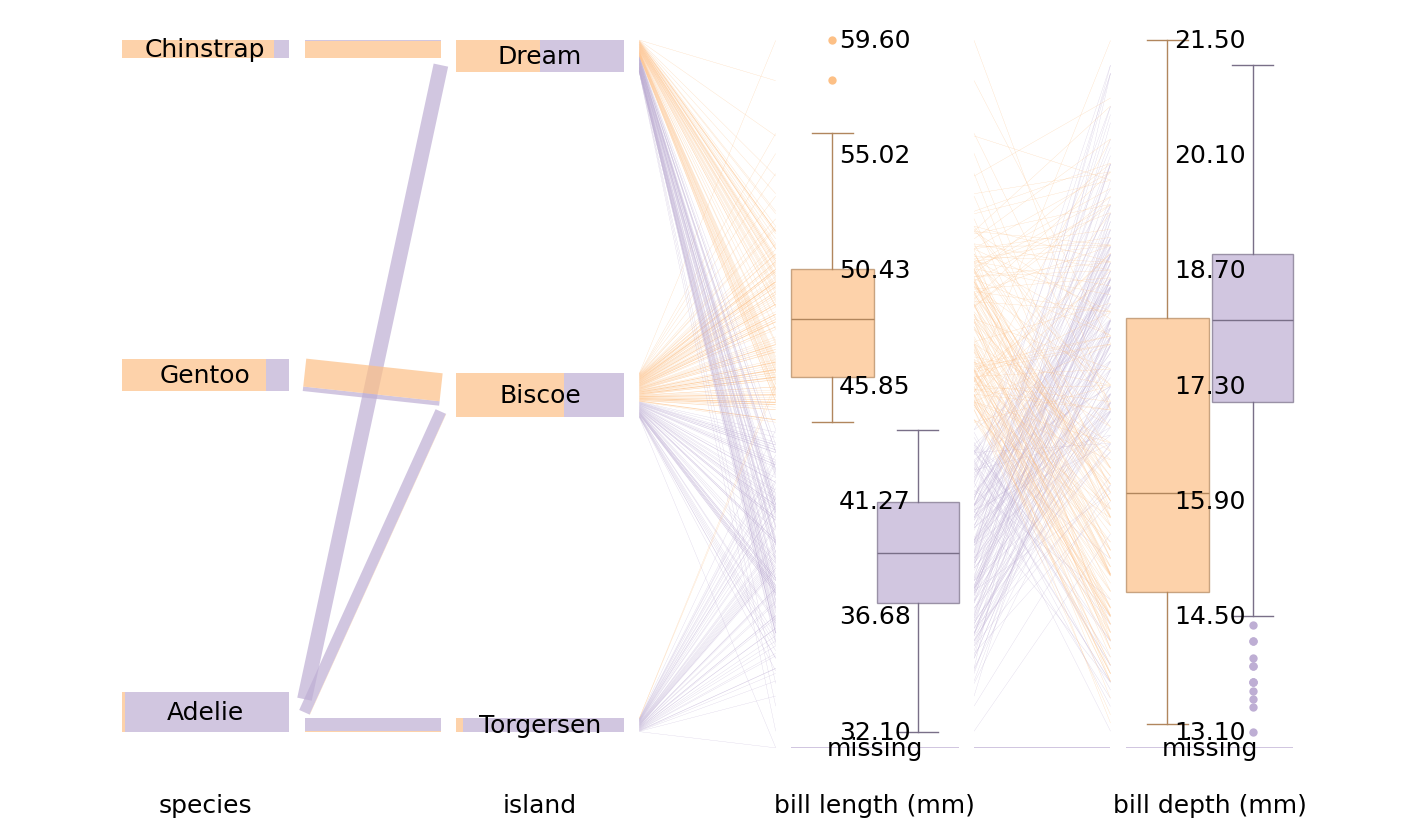

In [8]:
# highlighting example
hammock = hammock_plot.Hammock(df_penguins)
ax = hammock.plot(
    var= var_list,
    hi_var="bill length (mm)",
    hi_value="x>44.10",
    display_figure=True,
    missing=True,
    uni_vfill=0.15,
    label_options=label_options,
    uni_hfill=0.5,
    width=18,
    display_type={"bill length (mm)": "box", "bill depth (mm)": "box"},
)